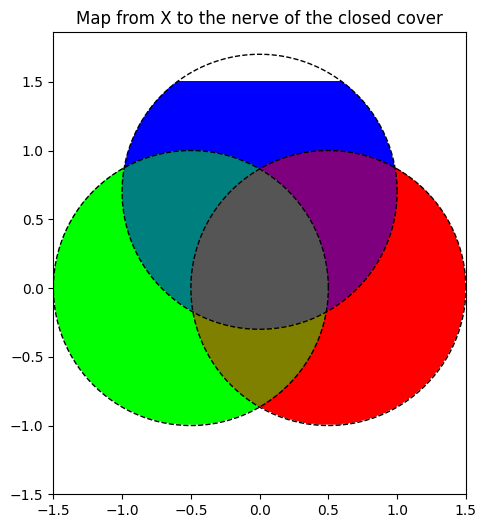

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Grid for the square space X
res = 500
x = np.linspace(-1.5, 1.5, res)
y = np.linspace(-1.5, 1.5, res)
X, Y = np.meshgrid(x, y)
points = np.stack([X, Y], axis=-1)

# Define closed cover sets U1, U2, U3 as discs
centers = np.array([[0.5, 0], [-0.5, 0], [0, 0.7]])
radii = np.array([1.0, 1.0, 1.0])

# Membership matrix: 1 if point in Ui, else 0
membership = np.zeros((res, res, len(centers)))
for i, (cx, cy) in enumerate(centers):
    dist = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2)
    membership[..., i] = (dist <= radii[i]).astype(float)

# Map to nerve using barycentric coordinates in Δ^2
# If point is in multiple Ui's, normalize membership to sum to 1
sum_mem = np.sum(membership, axis=-1, keepdims=True)
bary_coords = np.divide(membership, sum_mem, out=np.zeros_like(membership), where=sum_mem > 0)

# Assign colors to vertices of Δ^2
vertex_colors = np.array([[1, 0, 0],  # red for U1
                          [0, 1, 0],  # green for U2
                          [0, 0, 1]]) # blue for U3

# Color each point as barycentric combo
colors = bary_coords @ vertex_colors

# Points outside all sets: make white
colors[sum_mem[...,0] == 0] = [1, 1, 1]

# Plot
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(colors, origin='lower', extent=[-1.5, 1.5, -1.5, 1.5])
ax.set_aspect('equal')
ax.set_title("Map from X to the nerve of the closed cover")

# Draw the discs (boundaries of closed sets)
theta = np.linspace(0, 2*np.pi, 200)
for (cx, cy), r in zip(centers, radii):
    ax.plot(cx + r*np.cos(theta), cy + r*np.sin(theta), 'k--', lw=1)

plt.show()

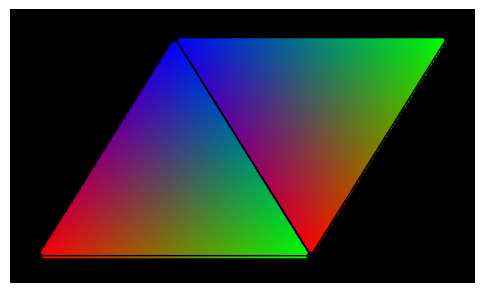

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection

# Example vertices (triangle vertices in the plane)
vertices = np.array([
    [0, 0],   # v0
    [1, 0],   # v1
    [0.5, 0.8],  # v2
    [1.5, 0.8]   # v3
])

# Example simplicial complex (list of triangles as vertex indices)
triangles = [
    [0, 1, 2],
    [1, 3, 2]
]

# Function to compute barycentric coordinates of a point wrt triangle
def barycentric_coords(p, tri):
    A = vertices[tri]
    T = np.hstack((A, np.ones((3, 1))))  # augmented coords
    P = np.array([p[0], p[1], 1.0])
    lambdas = np.linalg.solve(T.T, P)
    return lambdas

# Create a dense sampling of points to color
res = 300
x = np.linspace(-0.1, 1.6, res)
y = np.linspace(-0.1, 0.9, res)
X, Y = np.meshgrid(x, y)
points = np.c_[X.ravel(), Y.ravel()]

colors = np.zeros((points.shape[0], 3))

# Assign colors based on barycentric coords
for tri in triangles:
    A = vertices[tri]
    # Compute bounding box for efficiency
    minx, miny = A.min(axis=0)
    maxx, maxy = A.max(axis=0)
    mask = (
        (points[:, 0] >= minx) & (points[:, 0] <= maxx) &
        (points[:, 1] >= miny) & (points[:, 1] <= maxy)
    )
    for i in np.where(mask)[0]:
        lamb = barycentric_coords(points[i], tri)
        if np.all(lamb >= -1e-8):  # inside or on triangle
            colors[i] = np.clip(lamb, 0, 1)

# Plot mesh of triangles
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')

# Draw colored background
ax.scatter(points[:, 0], points[:, 1], color=colors, s=2, marker='s')

# Draw triangle edges
for tri in triangles:
    poly = vertices[tri]
    ax.plot(*zip(*(poly.tolist() + [poly[0]])), color='black', lw=1)

# Draw vertices
ax.scatter(vertices[:, 0], vertices[:, 1], c='black', zorder=5)

ax.set_xlim(-0.1, 1.6)
ax.set_ylim(-0.1, 0.9)
ax.axis('off')
plt.show()


In [114]:
class Ball:
    def __init__(self, center, radius):
        self.center = np.array(center)
        self.radius = radius

    def contains(self, point):
        return np.linalg.norm(point - self.center, axis=1) <= self.radius
    

SMALL_R = 1.3
BIG_R = 1.6
C1 = Ball([0.7, 1], SMALL_R)
U1 = Ball(C1.center, BIG_R)
C0 = Ball([-0.7, 1], SMALL_R)
U0 = Ball(C0.center, BIG_R)
C2 = Ball([0, -0.65], SMALL_R)
U2 = Ball(C2.center, BIG_R)
C3 = Ball([0, -2.3], SMALL_R)
U3 = Ball(C3.center, BIG_R)

C = [C0, C1, C2, C3]
U = [U0, U1, U2, U3]

centers_closed = np.array([c.center for c in C])
centers_open = np.array([u.center for u in U])

LOW = -4
UP = 3
LEFT = -3
RIGHT = 3
res = 500
x = np.linspace(LEFT, RIGHT, res)
y = np.linspace(LOW, UP, res)
X, Y = np.meshgrid(x, y)
points = np.c_[X.ravel(), Y.ravel()]


In [111]:
points.shape

(250000, 2)

In [115]:
# points = np.stack([X, Y], axis=-1)
inC = C0.contains(points) | C1.contains(points) | C2.contains(points) | C3.contains(points)
# inC = inC ^ 1

/tmp/ipykernel_31797/3321070643.py:16: RuntimeWarning: invalid value encountered in divide
  bary_coords = psis / np.sum(psis, axis=1, keepdims=True)


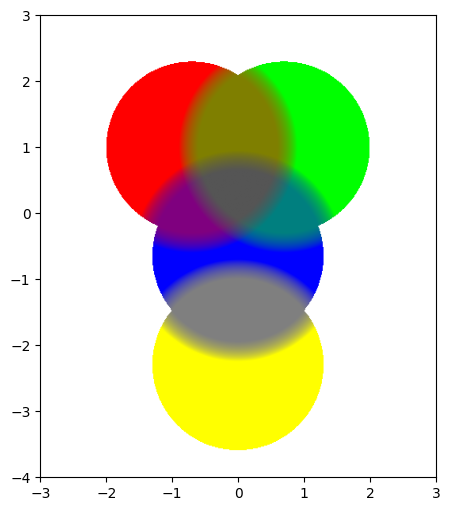

In [118]:


def dti(points, center, radius):
    return np.maximum(0, np.linalg.norm(points - center, axis=1) - radius)

def dto(points, center, radius):
    return np.maximum(0, radius - np.linalg.norm(points - center, axis=1))

def compute_barycentric_coordinates(points, closed_cover, open_cover):
    psis = []
    for c1, c2 in zip(closed_cover, open_cover):
        psi = np.zeros(points.shape[0])
        dtos = dto(points, c2.center, c2.radius)
        dtis = dti(points, c1.center, c1.radius)
        psi = dtos / (dtos + dtis)
        psis.append(psi)
    psis = np.array(psis).T
    bary_coords = psis / np.sum(psis, axis=1, keepdims=True)
    bary_coords[np.isnan(bary_coords)] = 0  # Handle division by zero
    return bary_coords

bary_coords = compute_barycentric_coordinates(points, C, U)
# Assign colors to vertices of Δ^3
vertex_colors = np.array([[1, 0, 0],  # red for U0
                          [0, 1, 0],  # green for U1
                          [0, 0, 1],  # blue for U2
                          [1, 1, 0]]) # yellow for U3
# Color each point as barycentric combo
colors = bary_coords @ vertex_colors

# Points outside all sets: make white
colors[inC == False] = [1, 1, 1]
# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(colors.reshape(res, res, 3), origin='lower', extent=[LEFT, RIGHT, LOW, UP])

ax.set_aspect('equal')
# Draw the discs (boundaries of closed sets)
# theta = np.linspace(0, 2 * np.pi, 200)
# for c in C:
#     ax.plot(c.center[0] + c.radius * np.cos(theta), c.center[1] + c.radius * np.sin(theta), 'k--', lw=1)
# plt.title("Map from X to the nerve of the closed cover")
plt.show()
# The code above visualizes the mapping from a square space to the nerve of a closed cover

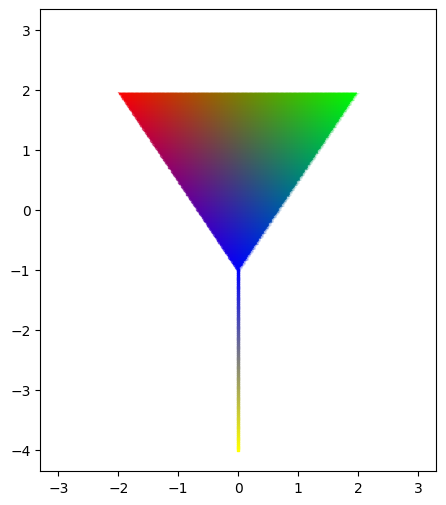

In [52]:
# Example vertices (triangle vertices in the plane)
vertices = np.array([
    [-1, 1],  # v0
    [1, 1],  # v1
    [0, -0.5],  # v2
    [0, -2]  # v3
]) * 2
# Example simplicial complex (list of triangles as vertex indices)
triangles = [
    [0, 1, 2]
]

# Function to compute barycentric coordinates of a point wrt triangle
def barycentric_coords(p, tri):
    A = vertices[tri]
    T = np.hstack((A, np.ones((3, 1))))  # augmented coords
    P = np.array([p[0], p[1], 1.0])
    lambdas = np.linalg.solve(T.T, P)
    return lambdas
# Create a dense sampling of points to color
x = np.linspace(LEFT, RIGHT, res)
y = np.linspace(LOW, UP, res)
X, Y = np.meshgrid(x, y)
points = np.c_[X.ravel(), Y.ravel()]
colors = np.zeros((points.shape[0], 3))
# Assign colors based on barycentric coords
for tri in triangles:
    A = vertices[tri]
    # Compute bounding box for efficiency
    minx, miny = A.min(axis=0)
    maxx, maxy = A.max(axis=0)
    mask = (
        (points[:, 0] >= minx) & (points[:, 0] <= maxx) &
        (points[:, 1] >= miny) & (points[:, 1] <= maxy)
    )
    for i in np.where(mask)[0]:
        lamb = barycentric_coords(points[i], tri)
        if np.all(lamb >= -1e-8):  # inside or on triangle
            colors[i] = np.clip(lamb, 0, 1)

# white background
colors[np.sum(colors, axis=1) == 0] = [1, 1, 1]

# Plot mesh of triangles
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
# Draw colored background
ax.scatter(points[:, 0], points[:, 1], color=colors, s=2, marker='s')
# Draw gradient colored edge from v2 o v3 with color changeing from blue to yellow
points_v2_v3 = np.linspace(vertices[2], vertices[3], 100)
colors_v2_v3 = np.linspace([0, 0, 1], [1, 1, 0], 100)
ax.scatter(points_v2_v3[:, 0], points_v2_v3[:, 1], color=colors_v2_v3, s=2, marker='s')
plt.show()


